# Численное моделирование распространения сейсмических волн в двумерной среде MILEN SEM 2D. Часть третья.

## Глава I: Геометрия тектонического разлома

### Задача

Построить геометрию модели с тектоническим разломом (сбросом), рассекающим все 75 слоёв.
Исходная модель загружается из Главы I.5, после чего через заданную точку проводится 
наклонная линия разлома, правый блок смещается вдоль неё на заданную величину.

Параметры разлома:
- `fault_x` — X-координата пересечения разлома с поверхностью
- `fault_angle` — угол наклона линии разлома относительно вертикали (градусы)
- `fault_throw` — вертикальное смещение слоёв вдоль разлома (метры)

In [1]:
# Импорты
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

## Параметры разлома ##

In [2]:
# Положение разлома — центр модели
fault_x = 5875.0  # м, X-координата пересечения с поверхностью

# Угол наклона относительно вертикали (0° — вертикальный разлом)
fault_angle = 0.0  # градусы

# Вертикальное смещение слоёв (положительное — правый блок опущен вниз)
fault_throw = 50.0  # м

## Загрузка исходной геометрии ##

In [3]:
data = np.load('data/dev_1_5_2_layer_boundaries_quadratic.npz', allow_pickle=True)

layer_boundaries = data['layer_boundaries_array']  # (75, 1176) — глубины нижних границ слоёв
formations = data['formations']                     # (75,) — названия формаций
distances = data['distances']                       # (1176,) — координаты вдоль профиля, м

print(f"Загружено слоёв: {layer_boundaries.shape[0]}")
print(f"Точек вдоль профиля: {layer_boundaries.shape[1]}")
print(f"Профиль: от {distances[0]:.0f} до {distances[-1]:.0f} м")
print(f"Шаг сетки: {distances[1] - distances[0]:.1f} м")

Загружено слоёв: 75
Точек вдоль профиля: 1176
Профиль: от 0 до 11750 м
Шаг сетки: 10.0 м


## Построение линии разлома ##

Линия разлома — прямая, проходящая через точку `(fault_x, 0)` на поверхности
под углом `fault_angle` от вертикали. При угле 0° разлом вертикальный;
при положительном угле верхняя часть наклонена вправо (нормальный сброс).

Уравнение линии разлома в координатах (x, z):

$$x_{fault}(z) = fault\_x + z \cdot \tan(\alpha)$$

где $\alpha$ — угол наклона от вертикали, $z$ — глубина (положительная вниз).

In [4]:
def fault_line_x(z, fault_x, fault_angle_deg):
    """
    X-координата линии разлома на глубине z.

    Args:
        z: глубина (м), скаляр или массив
        fault_x: X-координата на поверхности (м)
        fault_angle_deg: угол наклона от вертикали (градусы)

    Returns:
        X-координата линии разлома на глубине z
    """
    alpha = np.radians(fault_angle_deg)
    return fault_x + z * np.tan(alpha)

In [5]:
# Диапазон глубин модели
z_max = np.max(layer_boundaries)
z_range = np.linspace(0, z_max + fault_throw, 100)
x_fault_line = fault_line_x(z_range, fault_x, fault_angle)

print(f"\nЛиния разлома:")
print(f"  На поверхности: x = {fault_x:.0f} м")
print(f"  На глубине {z_max:.0f} м: x = {fault_line_x(z_max, fault_x, fault_angle):.0f} м")
print(f"  Угол от вертикали: {fault_angle}°")
print(f"  Смещение (throw): {fault_throw} м")


Линия разлома:
  На поверхности: x = 5875 м
  На глубине 2750 м: x = 5875 м
  Угол от вертикали: 0.0°
  Смещение (throw): 50.0 м


## Рассечение слоёв линией разлома ##

Для каждой границы слоя:
1. Находим точку пересечения границы с линией разлома (по X-координате)
2. Разделяем границу на левую и правую части
3. Правую часть смещаем вниз на `fault_throw`

Разлом резкий: слои слева и справа полностью независимы.
Смещение производится строго по вертикали — это соответствует модели нормального сброса,
где вертикальная компонента смещения (`throw`) задана явно.

In [6]:
def apply_fault_to_boundaries(layer_boundaries, distances, fault_x, fault_angle_deg, fault_throw):
    """
    Рассекает все границы слоёв линией разлома и смещает правый блок.

    Args:
        layer_boundaries: массив (N_layers, N_points) глубин границ
        distances: массив (N_points,) X-координат вдоль профиля
        fault_x: X-координата разлома на поверхности
        fault_angle_deg: угол наклона от вертикали (градусы)
        fault_throw: вертикальное смещение правого блока (м)

    Returns:
        faulted_boundaries: модифицированный массив границ (N_layers, N_points)
        fault_indices: индекс точки разлома для каждого слоя (N_layers,)
    """
    n_layers, n_points = layer_boundaries.shape
    faulted_boundaries = np.copy(layer_boundaries)
    fault_indices = np.zeros(n_layers, dtype=int)

    for i in range(n_layers):
        # Глубина текущей границы в точках профиля
        boundary_z = layer_boundaries[i]

        # X-координата линии разлома на глубине каждой точки профиля
        fault_x_at_depth = fault_line_x(boundary_z, fault_x, fault_angle_deg)

        # Находим индекс пересечения: где distances переходит через fault_x_at_depth
        crossings = distances - fault_x_at_depth
        sign_changes = np.where(np.diff(np.sign(crossings)))[0]

        if len(sign_changes) > 0:
            fault_idx = sign_changes[0]
        else:
            if crossings[0] > 0:
                fault_idx = 0
            else:
                fault_idx = n_points - 1

        fault_indices[i] = fault_idx

        # Смещаем правую часть границы вниз на fault_throw
        faulted_boundaries[i, fault_idx + 1:] = boundary_z[fault_idx + 1:] + fault_throw

        # Резкий разрыв: NaN в точке разлома (слои не соединяются)
        # faulted_boundaries[i, fault_idx] = np.nan

    return faulted_boundaries, fault_indices

In [7]:
# Применяем разлом
faulted_boundaries, fault_indices = apply_fault_to_boundaries(
    layer_boundaries, distances, fault_x, fault_angle, fault_throw
)

print(f"\nРазлом применён к {len(faulted_boundaries)} слоям")
print(f"Индексы разлома: от {fault_indices.min()} до {fault_indices.max()}")
print(f"X-координаты разлома: от {distances[fault_indices.min()]:.0f} до {distances[fault_indices.max()]:.0f} м")


Разлом применён к 75 слоям
Индексы разлома: от 587 до 587
X-координаты разлома: от 5870 до 5870 м


## Добавление поверхности (z=0) и плоского дна модели ##

Исходные данные `layer_boundaries_array` содержат только нижние границы слоёв (75 штук).
Для полного описания модели нужна верхняя граница (поверхность z=0) и плоское дно.

После разлома правый блок смещён вниз → формируются пустоты:
- **Вверху справа**: между z=0 и первой границей (заполняется растяжением первого слоя)
- **Внизу слева**: между последней границей и дном модели (заполняется растяжением последнего слоя)

Дно модели устанавливается плоским на отметке $z_{max} + fault\_throw$, 
что обеспечивает прямоугольную область расчёта.

In [8]:
# Глубина плоского дна модели (с учётом смещения)
model_bottom_depth = z_max + fault_throw

# Поверхность — z=0, с разрывом (NaN) в точке разлома на поверхности
surface = np.zeros(len(distances))
surface_fault_idx = np.searchsorted(distances, fault_x)
surface[surface_fault_idx] = np.nan

# Плоское дно модели — заполняет пустоту внизу слева (растяжение последнего слоя)
# Вычисляем позицию разлома на глубине model_bottom_depth
bottom_fault_x = fault_line_x(model_bottom_depth, fault_x, fault_angle)
bottom_fault_idx = np.searchsorted(distances, bottom_fault_x)
# Устанавливаем последнюю границу плоской (одинаковая глубина слева и справа)
faulted_boundaries[-1, :] = model_bottom_depth
faulted_boundaries[-1, bottom_fault_idx] = np.nan

# Полный массив границ: поверхность + 75 нижних границ = 76 линий
all_boundaries_original = np.vstack([np.zeros((1, len(distances))), layer_boundaries])
all_boundaries_faulted = np.vstack([surface[np.newaxis, :], faulted_boundaries])

print(f"\nПолный массив границ (с поверхностью): {all_boundaries_faulted.shape}")
print(f"Максимальная глубина (исходная): {layer_boundaries.max():.0f} м")
print(f"Глубина дна модели (плоское): {model_bottom_depth:.0f} м")
print(f"Первый слой справа растянут на {fault_throw:.0f} м (заполнение пустоты сверху)")
print(f"Последний слой слева растянут на {fault_throw:.0f} м (заполнение пустоты снизу)")


Полный массив границ (с поверхностью): (76, 1176)
Максимальная глубина (исходная): 2750 м
Глубина дна модели (плоское): 2800 м
Первый слой справа растянут на 50 м (заполнение пустоты сверху)
Последний слой слева растянут на 50 м (заполнение пустоты снизу)


## Коррекция перехлёстов слоёв ##

После смещения правого блока возможны перехлёсты: граница верхнего слоя может оказаться 
глубже нижнего слоя (отрицательная толщина). Это физически невозможно — корректируем, 
гарантируя минимальную толщину слоя 1 м. Точки разлома (NaN) пропускаются.

In [9]:
def fix_layer_overlaps(boundaries, min_thickness=1.0):
    """
    Исправляет перехлёсты слоёв, гарантируя минимальную толщину.
    Пропускает точки с NaN (разлом).

    Args:
        boundaries: массив (N_boundaries, N_points), включая поверхность
        min_thickness: минимально допустимая толщина слоя (м)

    Returns:
        fixed: исправленный массив границ
        n_fixes: количество исправленных точек
    """
    fixed = np.copy(boundaries)
    n_fixes = 0

    # Проходим сверху вниз, гарантируя что каждая граница глубже предыдущей
    for i in range(1, len(fixed)):
        diff = fixed[i] - fixed[i - 1]
        # Пропускаем NaN (точки разлома)
        valid = ~np.isnan(diff)
        mask = valid & (diff < min_thickness)
        if np.any(mask):
            n_fixes += np.sum(mask)
            fixed[i, mask] = fixed[i - 1, mask] + min_thickness

    return fixed, n_fixes

In [10]:
all_boundaries_faulted, n_fixes = fix_layer_overlaps(all_boundaries_faulted)
print(f"Исправлено перехлёстов: {n_fixes} точек")

# Извлекаем обратно только слоевые границы (без поверхности)
faulted_boundaries = all_boundaries_faulted[1:]

Исправлено перехлёстов: 0 точек


## Визуализация: исходная модель и модель с разломом ##

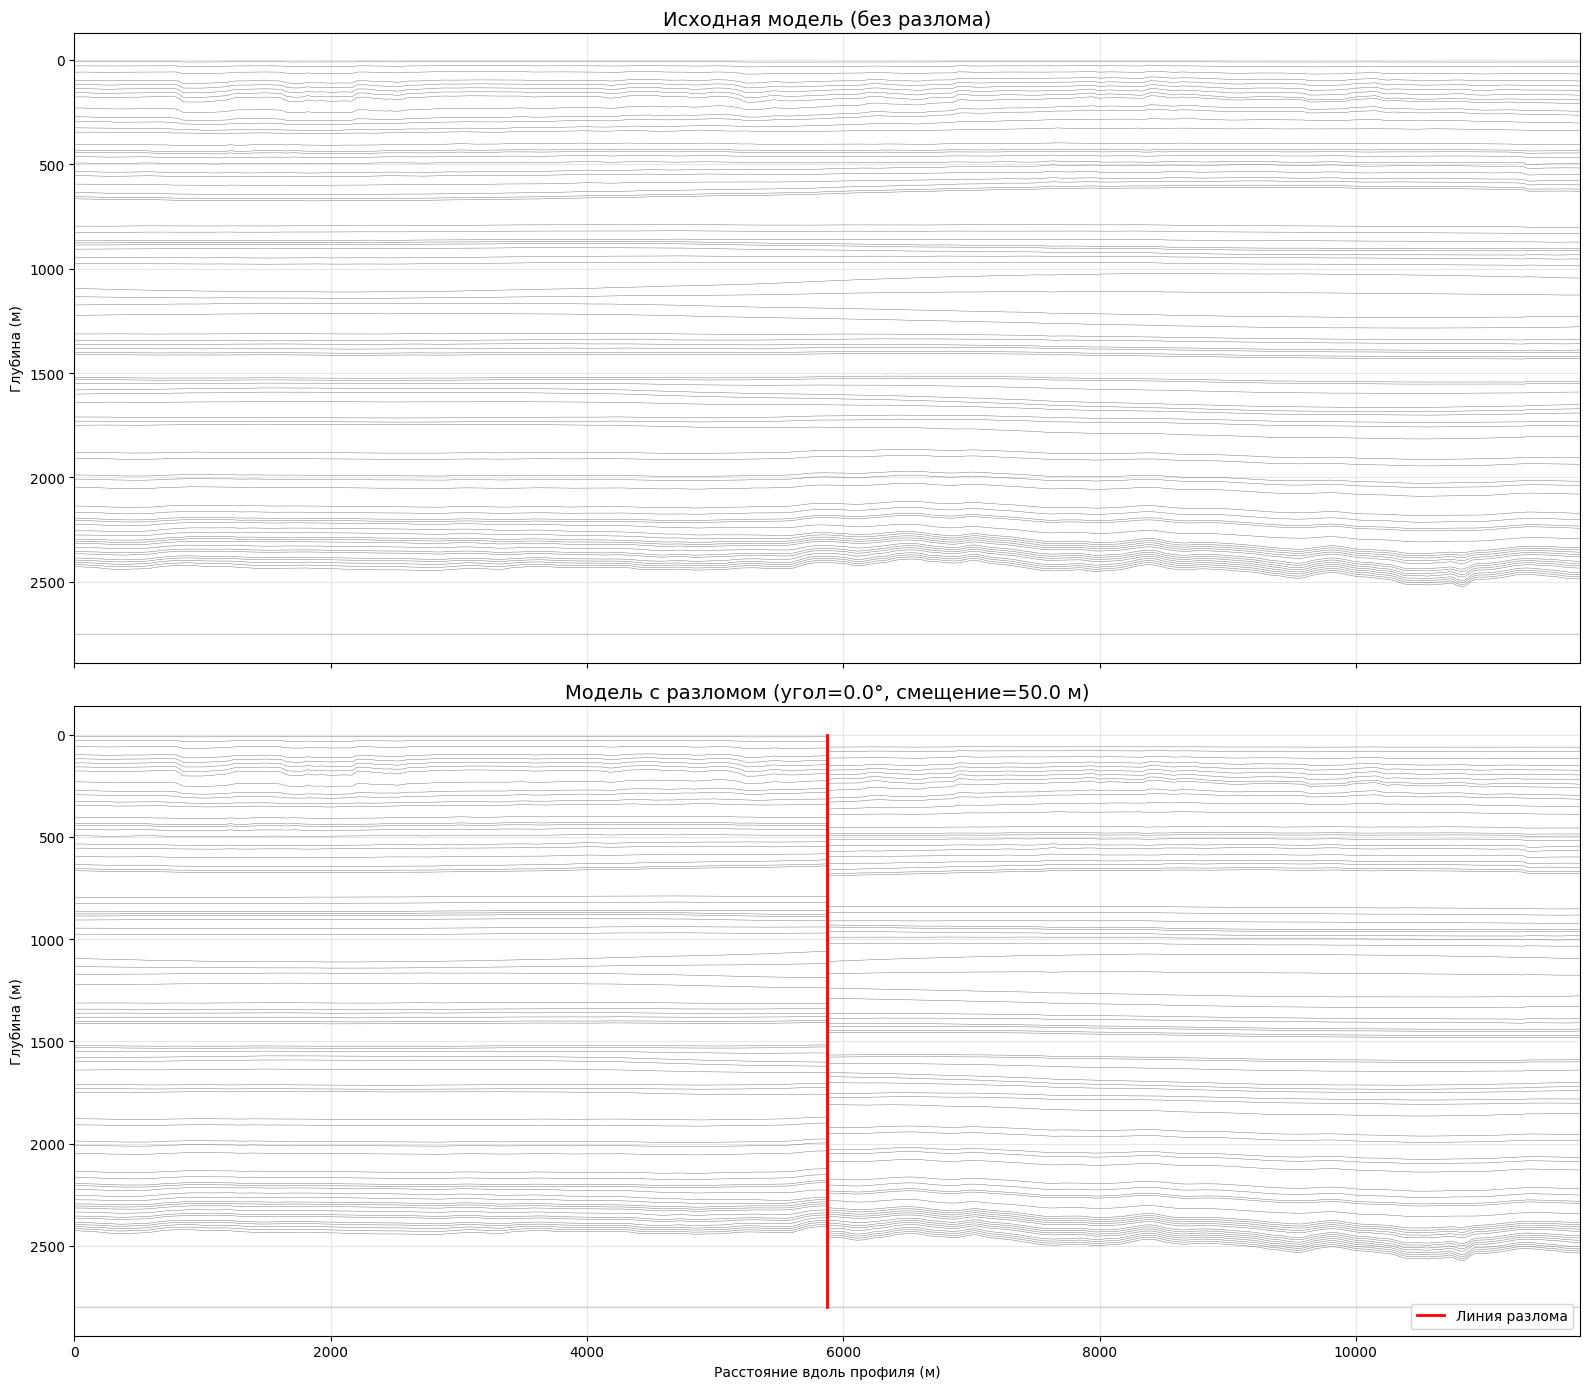

Сохранено: img/dev_3_1_fault_geometry_overview.png


In [11]:
fig, axes = plt.subplots(2, 1, figsize=(16, 14), sharex=True)

# --- Исходная модель ---
ax = axes[0]
ax.set_title('Исходная модель (без разлома)', fontsize=14)

for i in range(len(layer_boundaries)):
    ax.plot(distances, layer_boundaries[i], 'k-', linewidth=0.3, alpha=0.6)

ax.set_ylabel('Глубина (м)')
ax.invert_yaxis()
ax.grid(True, alpha=0.3)
ax.set_xlim(distances[0], distances[-1])

# --- Модель с разломом ---
ax = axes[1]
ax.set_title(f'Модель с разломом (угол={fault_angle}°, смещение={fault_throw} м)', fontsize=14)

for i in range(len(faulted_boundaries)):
    ax.plot(distances, faulted_boundaries[i], 'k-', linewidth=0.3, alpha=0.6)

# Линия разлома
ax.plot(x_fault_line, z_range, 'r-', linewidth=2, label='Линия разлома')

ax.set_xlabel('Расстояние вдоль профиля (м)')
ax.set_ylabel('Глубина (м)')
ax.invert_yaxis()
ax.grid(True, alpha=0.3)
ax.legend(loc='lower right')
ax.set_xlim(distances[0], distances[-1])

plt.tight_layout()
plt.savefig('img/dev_3_1_fault_geometry_overview.png', dpi=200, bbox_inches='tight')
plt.show()

print("Сохранено: img/dev_3_1_fault_geometry_overview.png")

## Визуализация: детальный вид зоны разлома ##

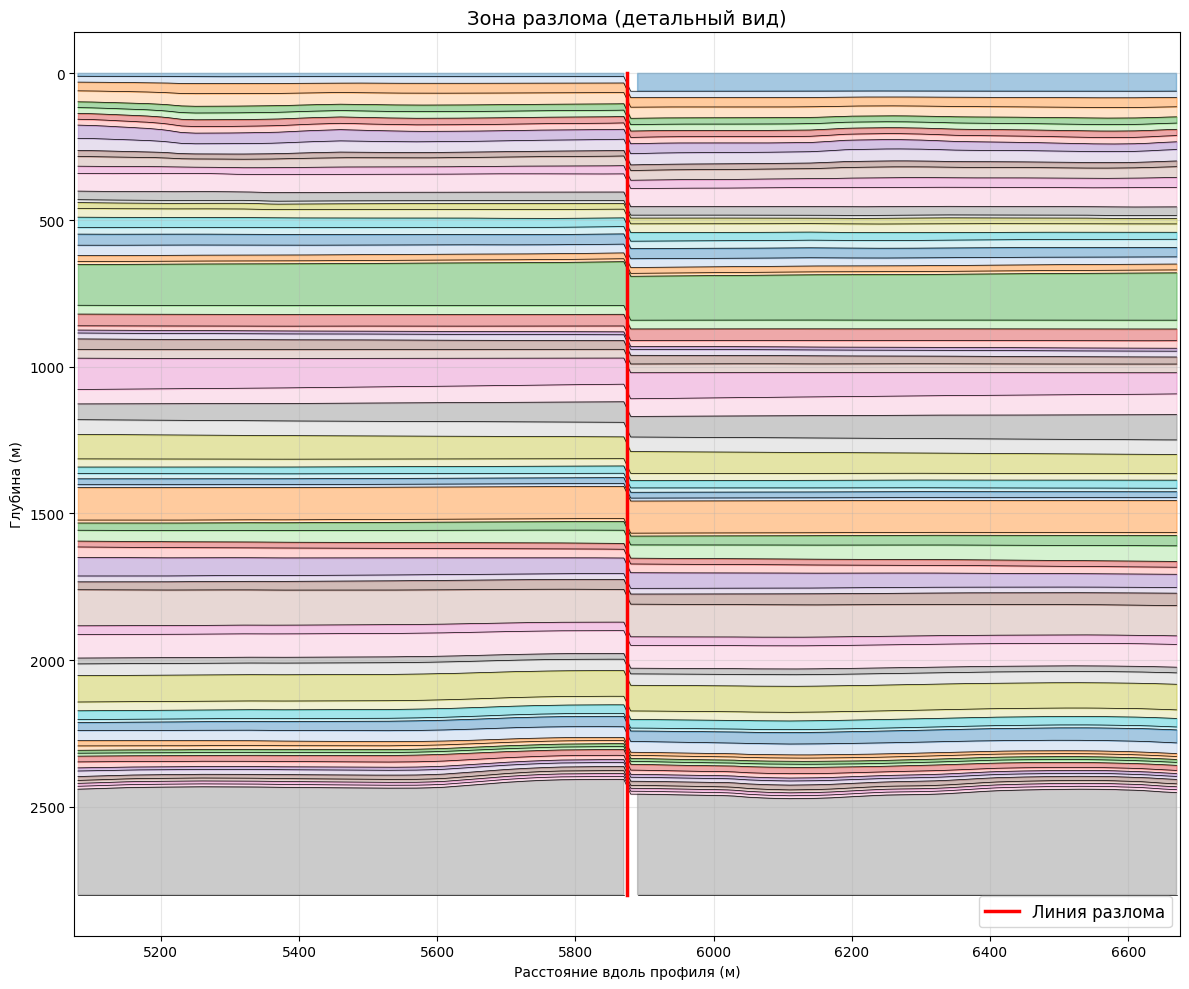

Сохранено: img/dev_3_1_fault_geometry_detail.png


In [12]:
# Центральная часть модели ±500 м от разлома
x_center = fault_x
x_left = x_center - 800
x_right = x_center + 800
mask_detail = (distances >= x_left) & (distances <= x_right)

fig, ax = plt.subplots(1, 1, figsize=(12, 10))
ax.set_title(f'Зона разлома (детальный вид)', fontsize=14)

# Цветная заливка слоёв
cmap = plt.cm.tab20
for i in range(len(faulted_boundaries)):
    upper = all_boundaries_faulted[i][mask_detail]
    lower = all_boundaries_faulted[i + 1][mask_detail]
    color = cmap(i % 20)
    ax.fill_between(distances[mask_detail], upper, lower, color=color, alpha=0.4)
    ax.plot(distances[mask_detail], faulted_boundaries[i][mask_detail], 'k-', linewidth=0.5)

# Линия разлома
ax.plot(x_fault_line, z_range, 'r-', linewidth=2.5, label='Линия разлома')

ax.set_xlabel('Расстояние вдоль профиля (м)')
ax.set_ylabel('Глубина (м)')
ax.invert_yaxis()
ax.grid(True, alpha=0.3)
ax.legend(loc='lower right', fontsize=12)
ax.set_xlim(x_left, x_right)

plt.tight_layout()
plt.savefig('img/dev_3_1_fault_geometry_detail.png', dpi=200, bbox_inches='tight')
plt.show()

print("Сохранено: img/dev_3_1_fault_geometry_detail.png")

## Сохранение результатов ##

In [13]:
np.savez('data/dev_3_1_fault_layer_boundaries.npz',
         layer_boundaries_array=faulted_boundaries,
         formations=formations,
         distances=distances,
         fault_x=fault_x,
         fault_angle=fault_angle,
         fault_throw=fault_throw,
         fault_indices=fault_indices,
         model_bottom_depth=model_bottom_depth)

print("\nРезультаты сохранены в data/dev_3_1_fault_layer_boundaries.npz")
print(f"  layer_boundaries_array: {faulted_boundaries.shape}")
print(f"  formations: {formations.shape}")
print(f"  distances: {distances.shape}")
print(f"  fault_x: {fault_x}")
print(f"  fault_angle: {fault_angle}")
print(f"  fault_throw: {fault_throw}")
print(f"  model_bottom_depth: {model_bottom_depth}")


Результаты сохранены в data/dev_3_1_fault_layer_boundaries.npz
  layer_boundaries_array: (75, 1176)
  formations: (75,)
  distances: (1176,)
  fault_x: 5875.0
  fault_angle: 0.0
  fault_throw: 50.0
  model_bottom_depth: 2800.0


## Выводы ##

Выполнено построение геометрии модели с тектоническим разломом:

1. Загружена исходная 75-слойная модель из Главы I.5
2. Задана линия разлома: x₀=5875 м, угол от вертикали — параметр
3. Все 75 границ слоёв рассечены линией разлома (резкий разрыв через NaN)
4. Правый блок смещён вниз на fault_throw (нормальный сброс)
5. Заполнены пустоты: первый слой справа и последний слой слева растянуты
   для формирования плоской поверхности сверху (z=0) и снизу (z=z_max+throw)
6. Выполнена коррекция перехлёстов слоёв (NaN-совместимая)
7. Построены графики: общий вид и детальный вид зоны разлома
8. Результаты сохранены в data/dev_3_1_fault_layer_boundaries.npz

Параметры разлома вынесены в начало скрипта и легко изменяются
для проведения параметрического исследования.